In [1]:
import warnings
warnings.filterwarnings(action='ignore',category=FutureWarning)
from utils import c2l_annotation
import anndata as ad
import pandas as pd
import scipy
import numpy as np
import hdf5plugin
import scanpy as sc
import math

/t9k/mnt/.conda/envs/cell2loc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/t9k/mnt/.conda/envs/cell2loc_env/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


## 先创建单细胞的模型

In [2]:
adata_sc = ad.read_h5ad('/t9k/mnt/zsk/workspace/HEST/project/Data/dataset/sc/Prostate_qc.h5ad')
adata_sc.X = adata_sc.X.astype('int32')

In [3]:
adata_sc.obs

,sample,study,major_cell_type,minor_cell_type,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb
cell_name,,,,,,,,,,,,
GAACCTAAGGTCATCT.1.0,1,Chen2021,Malignant,Malignant,2643,8084.0,0.0,0.000000,1961.0,24.257793,0.0,0.000000
TTGACTTTCGGACAAG.1.0,1,Chen2021,Malignant,Malignant,2543,9449.0,0.0,0.000000,4216.0,44.618477,0.0,0.000000
ATTACTCAGGAGCGAG.1.0,1,Chen2021,Malignant,Malignant,3240,12958.0,0.0,0.000000,5098.0,39.342491,0.0,0.000000
GCAGTTAAGCAGGCTA.1.0,1,Chen2021,Malignant,Malignant,3307,12079.0,0.0,0.000000,4506.0,37.304413,1.0,0.008279
GTCGGGTTCCTGTACC.1.0,1,Chen2021,Malignant,Malignant,3601,18873.0,0.0,0.000000,8823.0,46.749325,2.0,0.010597
...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTAGAAGT.1_6.2,patient #6,Dong2020,Epithelial,Epithelial,3921,29408.0,982.0,3.339227,14320.0,48.694233,1.0,0.003400
TTTGTTGTCAAACCCA.1_6.2,patient #6,Dong2020,Epithelial,Epithelial,1301,3179.0,77.0,2.422145,903.0,28.405159,1.0,0.031456
TTTGTTGTCAGACTGT.1_6.2,patient #6,Dong2020,Epithelial,Epithelial,3966,25487.0,822.0,3.225174,12317.0,48.326595,3.0,0.011771


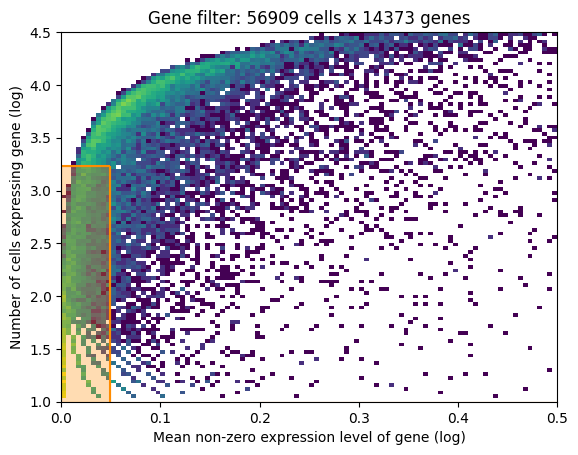

Anndata setup with scvi-tools version 1.2.1.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': 'major_cell_type',
│   'categorical_covariate_keys': ['Method'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  21   │
│         n_cells          │ 56909 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  10   │
│          n_vars          │ 14373 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

...

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Method'] │    3GEX    │          0          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/t9k/mnt/.conda/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/t9k/mnt/.conda/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=

Epoch 250/250: 100%|██████████| 250/250 [6:28:34<00:00, 152.99s/it, v_num=1, elbo_train=3.66e+8]   

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [6:28:34<00:00, 93.26s/it, v_num=1, elbo_train=3.66e+8] 


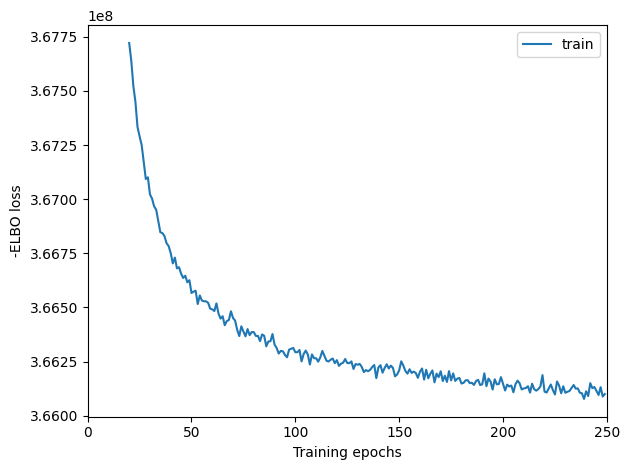

In [4]:
sc_mod,adata_ref = c2l_annotation.make_sc_model(adata_sc,l_k='major_cell_type',)

In [5]:
sc_mod.save('./cell2location_models/c2l_sc_model/prostate',overwrite=True)

Sampling local variables, batch:   0%|          | 0/23 [00:00<?, ?it/s]

Sampling global variables, sample: 100%|██████████| 999/999 [11:17<00:00,  1.48it/s]


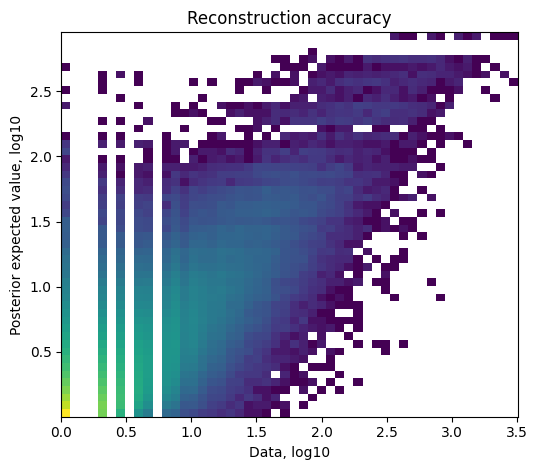

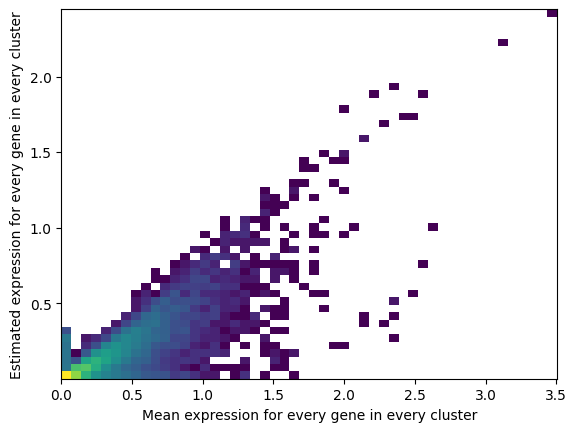

In [6]:
adata_ref = c2l_annotation.sc_posteriori(sc_mod,adata_ref)

In [ ]:
adata_ref.to_csv('./cell2location_models/c2l_sc_model/prostate/ref.csv')

## 利用已经训练好的单细胞模型和数据

In [ ]:
ref = pd.read_csv('./cell2location_models/c2l_sc_model/lung/ref.csv',index_col=0,sep=',')
adata_st = ad.read_h5ad('./temporary_data/10x_lung_st.h5ad')

训练空间转录组的model

In [2]:
adata_st = ad.read_h5ad('./temporary_data/10x_kidney_st.h5ad')
ref = pd.read_csv('./cell2location_models/c2l_sc_model/kindey/ref.csv',index_col=0)

/t9k/mnt/.conda/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
adata_st.obs.index = adata_st.obs['sample'].astype(object)+'_'+adata_st.obs.index

In [6]:
ref.columns.to_list()

['B',
 'Plasma',
 'T',
 'NK',
 'Myeloid',
 'Mast',
 'Pericyte',
 'Fibroblast',
 'Endothelial',
 'Epithelial',
 'Malignant']

spot数太多不能一次反卷积完

Anndata setup with scvi-tools version 1.2.1.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  14   │
│         n_cells          │ 60000 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 16233 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

...

Epoch 30000/30000: 100%|██████████| 30000/30000 [48:07<00:00, 10.40it/s, v_num=1, elbo_train=3.4e+6] 

`Trainer.fit` stopped: `max_epochs=30000` reached.


Sampling global variables, sample: 100%|██████████| 999/999 [00:20<00:00, 49.77it/s]


/t9k/mnt/.conda/envs/cell2loc_env/lib/python3.10/site-packages/cell2location/models/_cell2location_model.py:370: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[export_slot] = self._export2adata(self.samples)
/tmp/ipykernel_10733/3482475849.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotation_df['total'] = annotation_df[cells].sum(axis=1)


finish part 2 !


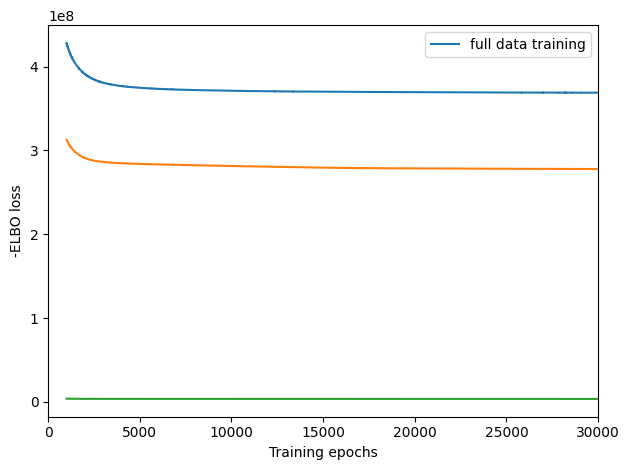

In [9]:
cut_length = 60000
times = math.ceil(len(adata_st)/cut_length)
anno_df_list = []
for i in range(times):
    adata = adata_st[i*cut_length:(i+1)*cut_length,:]
    st_mod = c2l_annotation.st_model(adata_st=adata,inf_aver=ref,num_cells_per_spot=25)
    adata = c2l_annotation.st_posteriori(st_mod,adata)
    adata.obs.columns = adata.obs.columns.str.rstrip()
    cells = ref.columns.to_list()
    annotation_df = adata.obs[cells]
    annotation_df['total'] = annotation_df[cells].sum(axis=1)
    annotation_df_pct = annotation_df[cells].div(annotation_df['total'],axis=0)
    annotation_df.to_csv(f'/t9k/mnt/zsk/workspace/HEST/project/data_process/single_cell_annotation/annotation_output/Kidney/cell2location/10X_{i}.csv',index=True)
    annotation_df_pct.to_csv(f'/t9k/mnt/zsk/workspace/HEST/project/data_process/single_cell_annotation/annotation_output/Kidney/cell2location/10X_pct_{i}.csv',index=True)
    anno_df_list.append(annotation_df_pct)
    print(f'finish part {i} !')
anno_all =pd.concat(anno_df_list,axis=0,join='outer')
anno_all.to_csv('/t9k/mnt/zsk/workspace/HEST/project/data_process/single_cell_annotation/annotation_output/Kidney/cell2location/10X_pct_all.csv',index=True)

In [ ]:
st_mod = c2l_annotation.st_model(adata_st=adata_st,inf_aver=ref,num_cells_per_spot=25)

In [ ]:
adata_st = c2l_annotation.st_posteriori(st_mod,adata_st)

Sampling global variables, sample: 100%|██████████| 999/999 [01:17<00:00, 12.91it/s]


In [11]:
adata_st

AnnData object with n_obs × n_vars = 69643 × 71774
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'sample', 'pxl_row_in_fullres_old', 'pxl_col_in_fullres_old', 'B', 'Plasma', 'T', 'NK', 'Myeloid', 'Mast', 'Pericyte', 'Fibroblast', 'Endothelial', 'Epithelial', 'Malignant'
    uns: 'mod'
    obsm: 'spatial', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf'

In [22]:
adata_st.obs.columns = adata_st.obs.columns.str.rstrip()

In [23]:
adata_st.obs.columns

Index(['in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres',
       'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mito',
       'log1p_total_counts_mito', 'pct_counts_mito', 'sample',
       'pxl_row_in_fullres_old', 'pxl_col_in_fullres_old', 'B', 'Plasma', 'T',
       'NK', 'Myeloid', 'Mast', 'Fibroblast', 'Endothelial', 'Epithelial',
       'Malignant'],
      dtype='object')

In [24]:
cells = ['B', 'Plasma', 'T','NK', 'Myeloid', 'Mast', 'Fibroblast', 'Endothelial', 'Epithelial','Malignant']
annotation_df = adata_st.obs[cells]

In [25]:
annotation_df

,B,Plasma,T,NK,Myeloid,Mast,Fibroblast,Endothelial,Epithelial,Malignant
TENX72_AACAATCCGAGTGGAC-1,0.136594,1.926656,0.206385,0.364993,0.101859,0.170960,0.395399,0.862109,0.294920,12.119193
TENX72_AACAATGGAACCACAT-1,0.193335,0.985818,0.152472,0.131402,0.199074,0.233775,1.456850,2.732095,0.175439,8.417665
TENX72_AACACCAGCCTACTCG-1,0.095363,1.004466,0.082108,0.112425,0.061025,0.121366,0.100461,0.380847,0.048111,8.340831
TENX72_AACACCATTCGCATAC-1,0.098644,1.539293,0.077271,0.138185,0.009750,0.282175,0.211996,1.158008,0.095550,9.770935
TENX72_AACACCGAGCTTGGAT-1,0.382017,1.165522,0.136650,0.120071,0.177752,0.168054,0.290701,0.880931,0.111788,8.302711
...,...,...,...,...,...,...,...,...,...,...
MISC13_TTGTGGTATAGGTATG-1,0.110484,0.230590,0.212044,0.143658,0.098832,0.061083,3.094648,1.182712,0.133152,0.085467
MISC13_TTGTTCAGTGTGCTAC-1,0.226157,1.469288,0.174886,0.252705,0.150660,0.010089,0.156279,0.201382,0.312773,1.438798
MISC13_TTGTTGTGTGTCAAGA-1,0.032335,0.326009,0.038988,0.019650,0.017247,0.013030,0.283468,0.080857,0.083755,0.852225
MISC13_TTGTTTCATTAGTCTA-1,0.099834,0.067717,0.157911,0.092046,0.122238,0.042592,2.854632,1.062351,0.143395,0.081442


In [26]:
annotation_df['total'] = annotation_df[cells].sum(axis=1)

/tmp/ipykernel_3720973/3755072267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotation_df['total'] = annotation_df[cells].sum(axis=1)


In [27]:
annotation_df_pct = annotation_df[cells].div(annotation_df['total'],axis=0)

In [29]:
annotation_df_pct.to_csv('/t9k/mnt/zsk/workspace/HEST/project/mulitimodel_fusion/single_cell_annotation/annotation_output/Lung/cell2location/10X_pct.csv',index=True)

In [30]:
annotation_df.to_csv('/t9k/mnt/zsk/workspace/HEST/project/mulitimodel_fusion/single_cell_annotation/annotation_output/Lung/cell2location/10X.csv',index=True)